**INTRODUCTION**

# Iris Flower Classification using Machine Learning

## Objective
The goal of this project is to classify iris flowers into three species:
- Iris Setosa
- Iris Versicolor
- Iris Virginica

using machine learning algorithms based on flower measurements.

## Features Used
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**LOAD DATASET**

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**DATA ANALYSIS**

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
print(df.shape)

(150, 5)


**DATA VISUALIZATION**

In [8]:
sns.set_theme(style="whitegrid")

In [10]:
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

**SPECIES DISTRIBUTION**


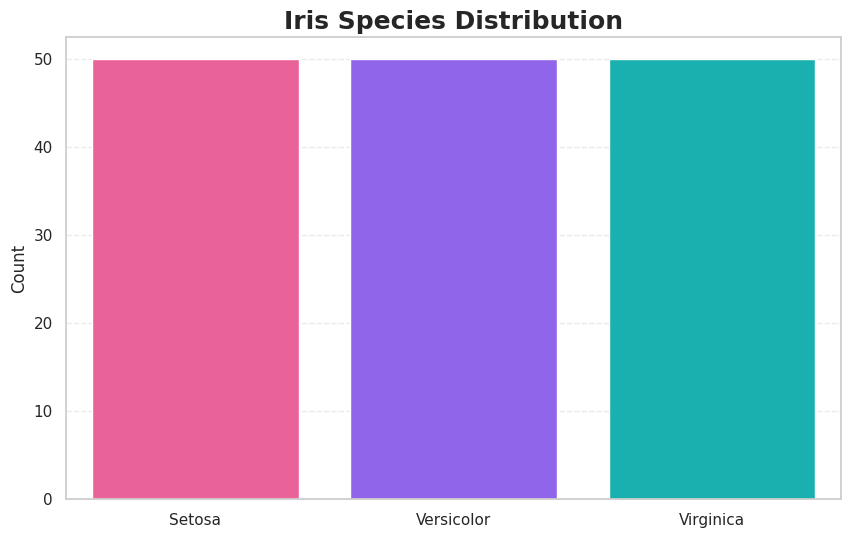

In [12]:
plt.figure(figsize=(10,6))

colors = ["#ff4d94", "#8a4fff", "#00c9c8"]

sns.countplot(
    x="species_name",
    hue="species_name",
    data=df,
    palette=colors,
    legend=False
)

plt.title("Iris Species Distribution", fontsize=18, fontweight='bold')
plt.xlabel("")
plt.ylabel("Count", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

**PETAL LENGTH DISTRIBUTION**

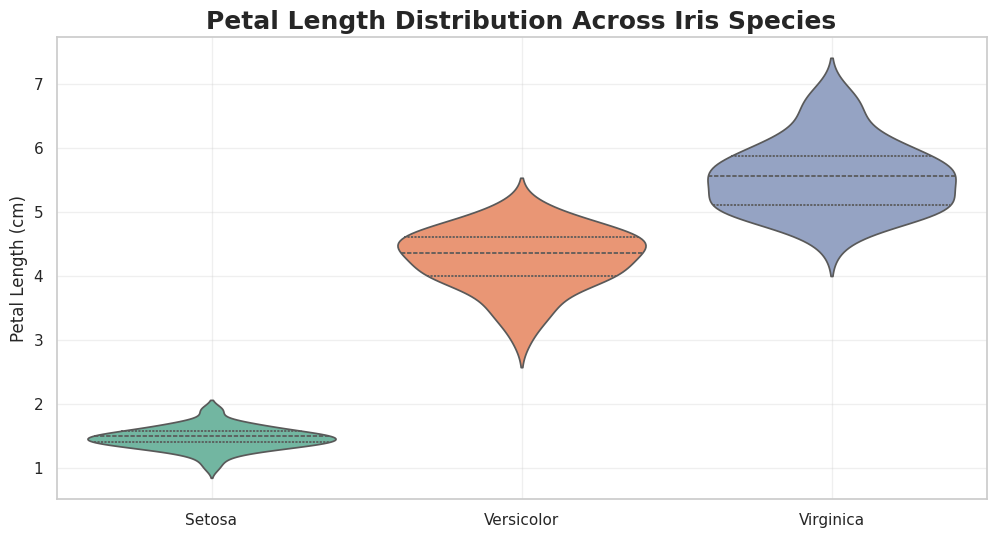

In [14]:
plt.figure(figsize=(12,6))

sns.violinplot(
    x="species_name",
    y="petal length (cm)",
    hue="species_name",
    data=df,
    palette="Set2",
    legend=False,
    inner="quartile"
)

plt.title(
    "Petal Length Distribution Across Iris Species",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("")
plt.ylabel("Petal Length (cm)")

plt.grid(alpha=0.3)

plt.show()

**PAIR PLOT**

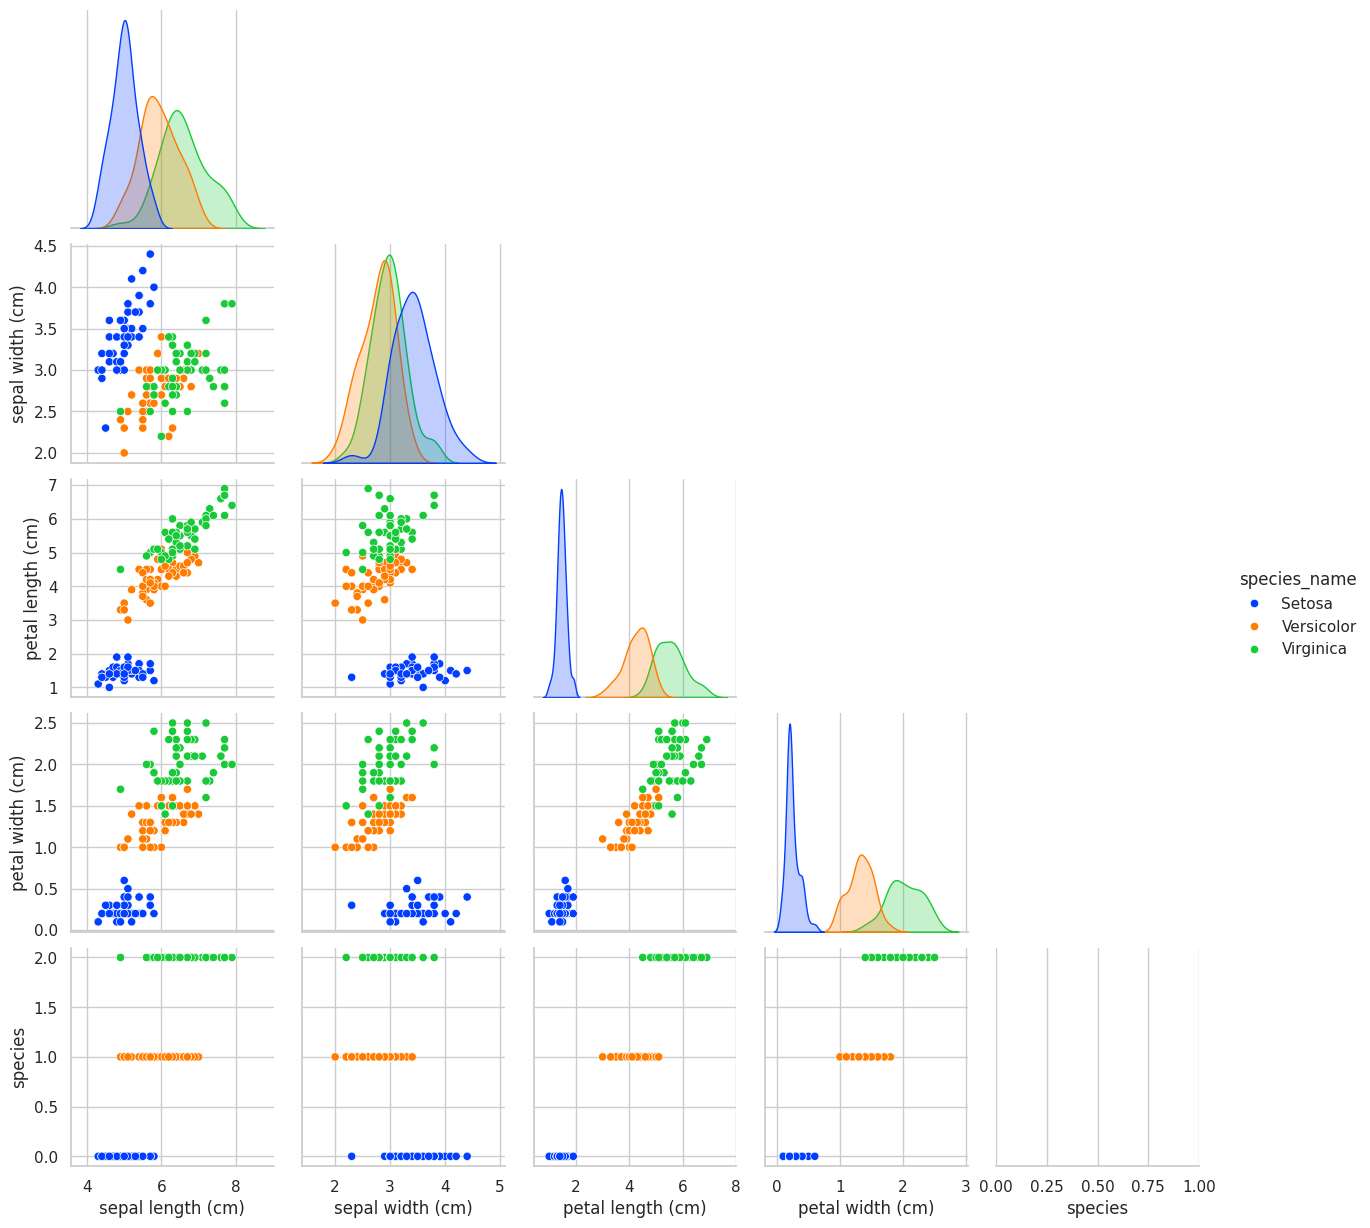

In [15]:
sns.pairplot(
    df,
    hue="species_name",
    palette="bright",
    diag_kind="kde",
    corner=True
)

plt.show()

**HEAT MAP**

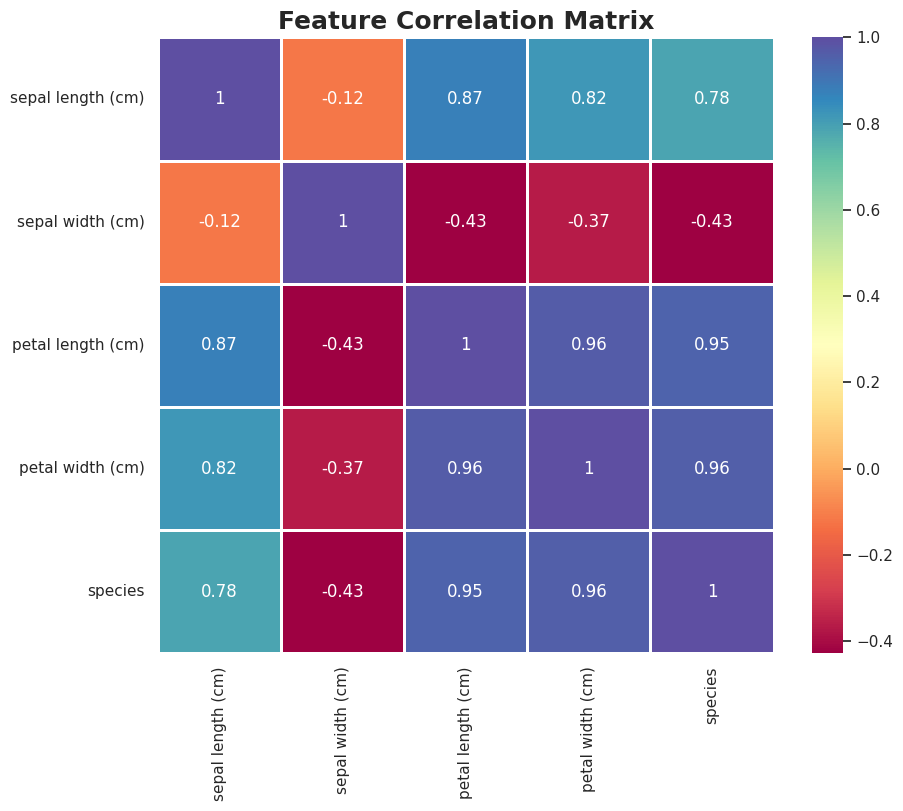

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("species_name", axis=1).corr(numeric_only=True),
    annot=True,
    cmap="Spectral",
    linewidths=2,
    square=True
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.show()

**RADAR CHART**

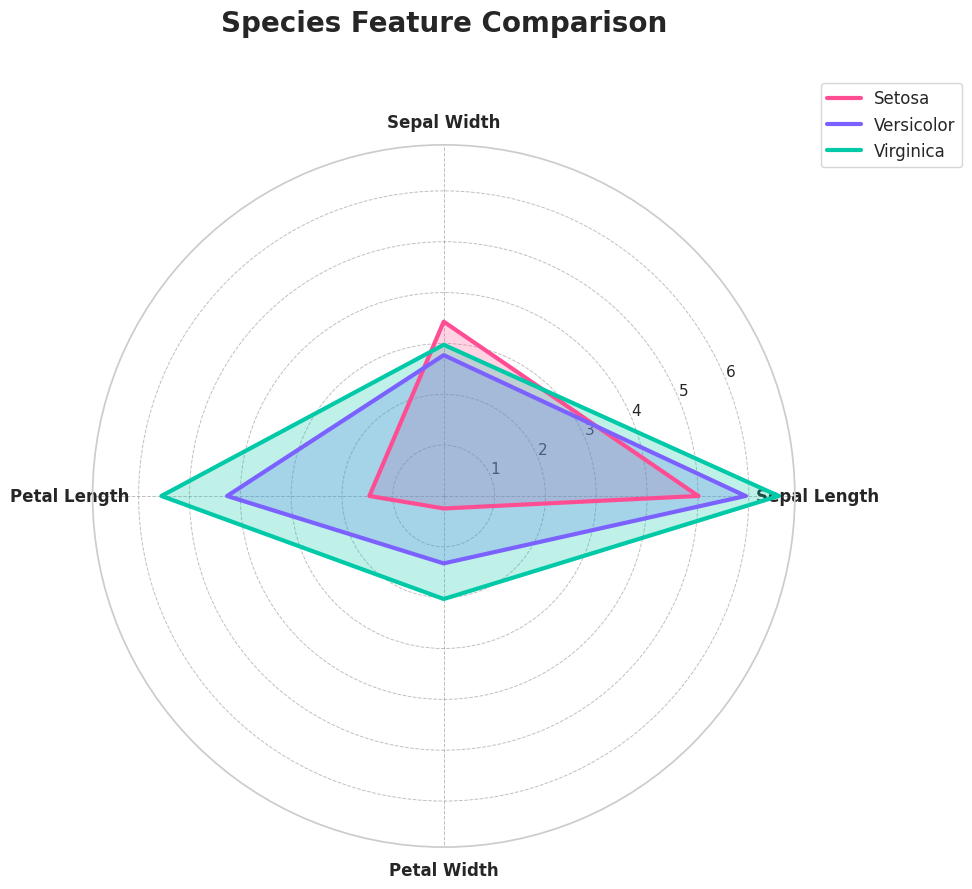

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Professional Style
sns.set_theme(style="whitegrid")

# Short Feature Names
labels = [
    "Sepal Length",
    "Sepal Width",
    "Petal Length",
    "Petal Width"
]

# Calculate Mean Values
means = df.groupby("species_name")[iris.feature_names].mean()

# Radar Chart Setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

# Create Figure
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Attractive Colors
colors = [
    "#FF4D94",   # Pink
    "#7B61FF",   # Purple
    "#00C9A7"    # Teal
]

# Plot Each Species
for species, color in zip(means.index, colors):

    values = means.loc[species].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=3,
        color=color,
        label=species
    )

    ax.fill(
        angles,
        values,
        color=color,
        alpha=0.25
    )

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    labels,
    fontsize=12,
    fontweight='bold'
)

# Grid Styling
ax.grid(
    color='gray',
    linestyle='--',
    linewidth=0.7,
    alpha=0.5
)

# Title
plt.title(
    "Species Feature Comparison",
    fontsize=20,
    fontweight='bold',
    y=1.15
)

# Legend
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.10),
    fontsize=12
)

plt.tight_layout()
plt.show()

**FEATURE DISTRIBUTION**

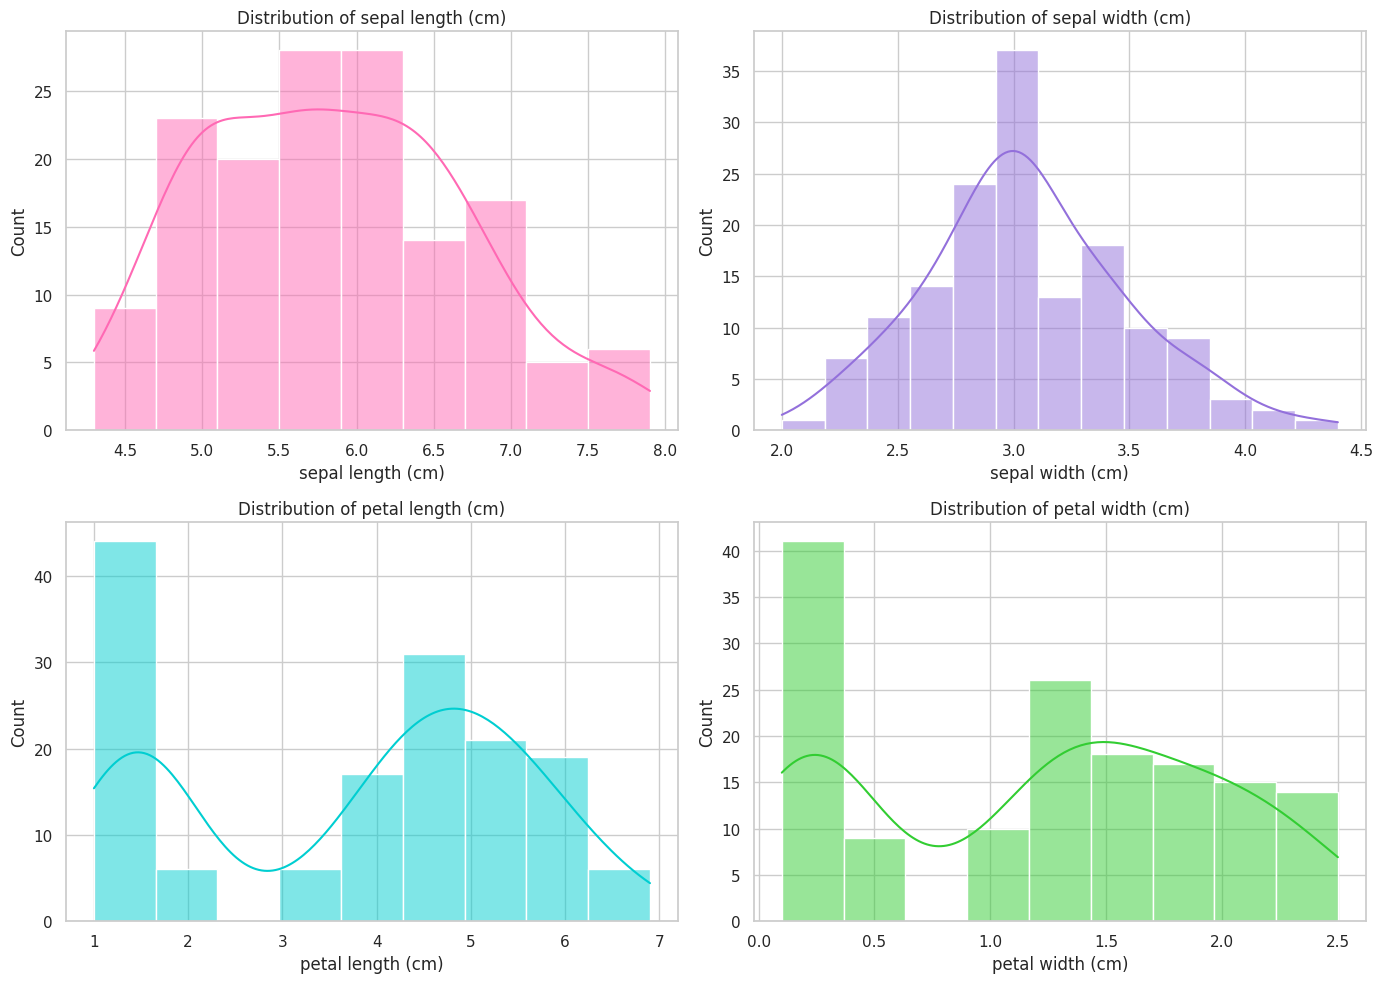

In [20]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

features = iris.feature_names

colors = [
    "#FF69B4",
    "#9370DB",
    "#00CED1",
    "#32CD32"
]

for i, ax in enumerate(axes.flat):

    sns.histplot(
        df[features[i]],
        kde=True,
        color=colors[i],
        ax=ax
    )

    ax.set_title(
        f"Distribution of {features[i]}",
        fontsize=12
    )

plt.tight_layout()
plt.show()

**TRAIN TEST SPLIT**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**KNN MODEL**

In [23]:
knn = KNeighborsClassifier()

knn.fit(
    X_train,
    y_train
)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 1.0


**RANDOM FOREST**

In [24]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


**CONFUSION MATRIX**

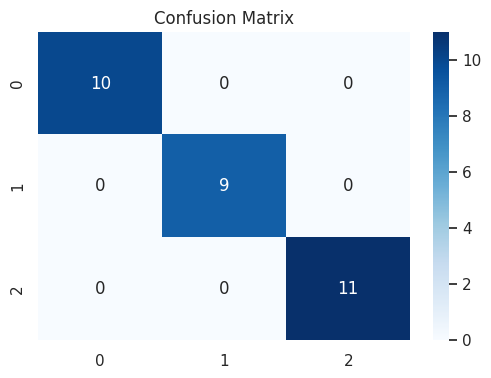

In [25]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

**CLASSIFICATION REPORT**

In [26]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**MODEL COMPARISION CHART**

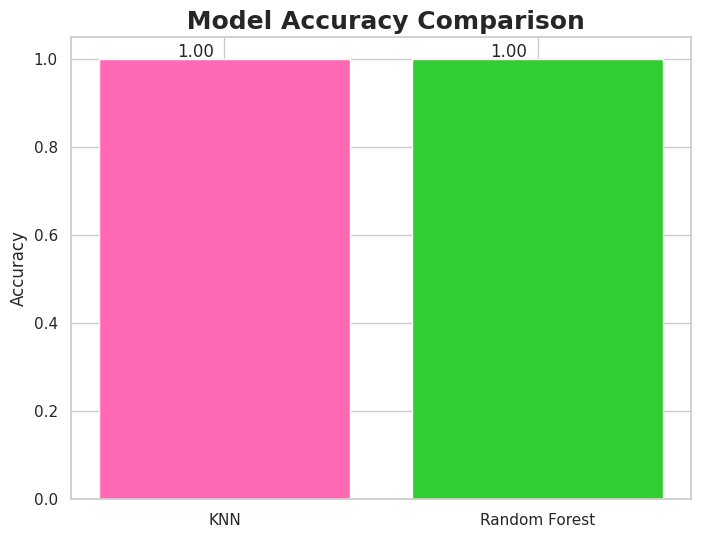

In [29]:
models = ["KNN", "Random Forest"]
scores = [knn_acc, rf_acc]

plt.figure(figsize=(8,6))

bars = plt.bar(
    models,
    scores,
    color=["#FF69B4","#32CD32"]
)

plt.title(
    " Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Accuracy")

for bar in bars:
    plt.text(
        bar.get_x()+0.25,
        bar.get_height()+0.005,
        f"{bar.get_height():.2f}",
        fontsize=12
    )

plt.show()

**SAMPLE PREDICTION**

In [30]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = rf.predict(sample)

species_names = [
    "Setosa",
    "Versicolor",
    "Virginica"
]

print(
    "Predicted Species:",
    species_names[prediction[0]]
)

Predicted Species: Setosa


## Conclusion

This project successfully classified iris flowers using machine learning.

Models Used:
- KNN
- Random Forest

Random Forest achieved the best performance and accurately classified the flower species.

The project demonstrates:
- Data Analysis
- Data Visualization
- Machine Learning
- Model Evaluation
